In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [33]:
steam_data = pd.read_csv('steam.csv') # Load the dataset
#Checking the dataset
steam_data.head()


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [34]:
steam_data.info()
steam_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [35]:
steam_data.isnull().sum() # Check for missing values

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

In [36]:
steam_data.dropna(inplace=True) # Remove rows with missing values 
steam_data.shape

(27061, 18)

In [37]:
steam_data['date_year'] = pd.to_datetime(steam_data['release_date'], errors='coerce').dt.year #Extract release year from release_date
cat_features = ['platforms', 'genres', 'categories', 'steamspy_tags'] #Categorical features
num_features = num_features = ['price', 'achievements', 'date_year'] #Numerical features

# Create target variable if positive ratings are more than 70% of total ratings, label as successful (1), else not successful (0)
steam_data['success'] = (steam_data['positive_ratings'] /(steam_data['positive_ratings'] + steam_data['negative_ratings']) > 0.7).astype(int)

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [38]:
pipe_lr = Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=1000))]) # Logistic Regression pipeline
pipe_rf = Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(n_estimators=200))]) # Random Forest pipeline
pipe_svm = Pipeline([('preprocessor', preprocessor), ('model', SVC(kernel='rbf', probability=True))]) # SVM pipeline

In [39]:
X = steam_data[['price', 'achievements', 'platforms', 'genres', 'categories', 'steamspy_tags', 'date_year']]
y = steam_data['success']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['price', 'achievements',
                                                   'date_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['platforms', 'genres',
                                                   'categories',
                                                   'steamspy_tags'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [42]:

pipe_rf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['price', 'achievements',
                                                   'date_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['platforms', 'genres',
                                                   'categories',
                                                   'steamspy_tags'])])),
                ('model', RandomForestClassifier(n_estimators=200))])

In [43]:
pipe_svm.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['price', 'achievements',
                                                   'date_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['platforms', 'genres',
                                                   'categories',
                                                   'steamspy_tags'])])),
                ('model', SVC(probability=True))])

In [44]:
    #comparing model using real answers and predicted answers
print("Logistic Regression Classification:")
y_pred_lr = pipe_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

print("Random Forest Classification:")
y_pred_rf = pipe_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

print("SVM Classification:")
y_pred_svm = pipe_svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))

Logistic Regression Classification:
              precision    recall  f1-score   support

           0       0.57      0.42      0.48      2165
           1       0.67      0.78      0.72      3248

    accuracy                           0.64      5413
   macro avg       0.62      0.60      0.60      5413
weighted avg       0.63      0.64      0.63      5413

Random Forest Classification:
              precision    recall  f1-score   support

           0       0.61      0.40      0.48      2165
           1       0.68      0.83      0.75      3248

    accuracy                           0.66      5413
   macro avg       0.64      0.62      0.61      5413
weighted avg       0.65      0.66      0.64      5413

SVM Classification:
              precision    recall  f1-score   support

           0       0.64      0.06      0.12      2165
           1       0.61      0.98      0.75      3248

    accuracy                           0.61      5413
   macro avg       0.63      0.52      0.4

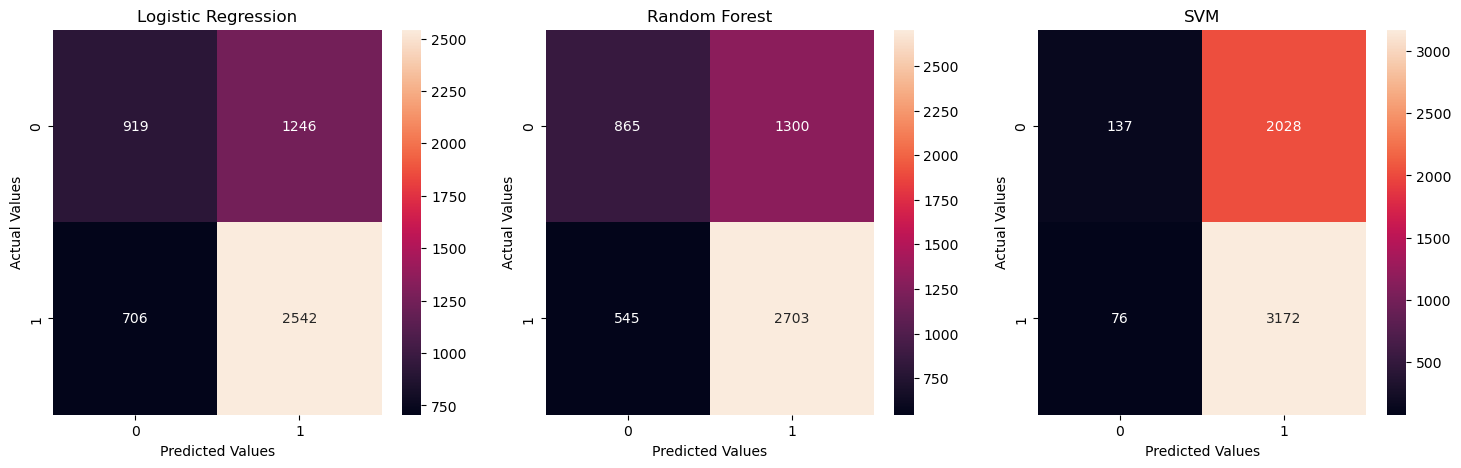

In [45]:
# for visual results 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)


sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Actual Values')

sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual Values')

sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[2])
axes[2].set_title('SVM')
axes[2].set_xlabel('Predicted Values')
axes[2].set_ylabel('Actual Values')

plt.show()

In [46]:
import pickle

with open('model_lr.pkl', 'wb') as f:
    pickle.dump(pipe_lr, f)

with open('model_rf.pkl', 'wb') as f:
    pickle.dump(pipe_rf, f)

with open('model_svm.pkl', 'wb') as f:
    pickle.dump(pipe_svm, f)
